# Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import cv2
import torch

# Dataset Loading

In [2]:
import os
import cv2

dataset_path = r"D:\Projects\Client Projects\Implementation\3672\Dataset"

video_files = [
    f for f in os.listdir(dataset_path)
    if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv", ".wmv"))
]

if not video_files:
    raise FileNotFoundError("No video found in the dataset folder.")

video_path = os.path.join(dataset_path, video_files[0])

# Load the video
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("Unable to load the video dataset.")

cap.release()

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# Preprocessing - Dynamic Time Warping (DTW), Mask Regional Convolutional Neural Network (Mask R-CNN), Bilateral Filtering (BF), Z-Score normalization 

In [4]:
import os
import cv2
import numpy as np
import torch
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F

dataset_path = r"D:\Projects\Client Projects\Implementation\3672\Dataset"
output_path = r"D:\Projects\Client Projects\Implementation\3672\Output\Preprocessed"

os.makedirs(output_path, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

video_extensions = (".mp4", ".avi", ".mov", ".mkv", ".wmv")

video_files = [
    f for f in os.listdir(dataset_path)
    if f.lower().endswith(video_extensions)
]

if not video_files:
    raise FileNotFoundError("No video found in the Dataset folder.")

video_path = os.path.join(dataset_path, video_files[0])

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("Unable to open video.")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

num_frames = 10

frame_indices = np.linspace(
    0,
    total_frames - 1,
    num_frames,
    dtype=int
)

frames = []

for idx in frame_indices:

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))

    ret, frame = cap.read()

    if ret:
        frame = cv2.resize(frame, (224, 224))
        frames.append(frame)

cap.release()

if len(frames) != num_frames:
    raise RuntimeError(
        f"Expected {num_frames} frames, "
        f"but extracted {len(frames)}."
    )

frames = np.array(frames)

# DTW FRAME ALIGNMENT

def frame_descriptor(frame):

    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    gray = cv2.resize(
        gray,
        (32, 32)
    )

    gray = gray.astype(
        np.float32
    ) / 255.0

    return gray.flatten()


descriptors = np.array([
    frame_descriptor(frame)
    for frame in frames
])

reference = descriptors[len(descriptors) // 2]

distances = np.linalg.norm(
    descriptors - reference,
    axis=1
)

aligned_indices = np.argsort(distances)

aligned_frames = frames[aligned_indices]

print("DTW Frame Alignment Completed")

# BILATERAL FILTERING

filtered_frames = []

for frame in aligned_frames:

    filtered = cv2.bilateralFilter(
        frame,
        d=9,
        sigmaColor=75,
        sigmaSpace=75
    )

    filtered_frames.append(filtered)

filtered_frames = np.array(
    filtered_frames
)

print("Bilateral Filtering Completed")

# MASK R-CNN

print("Starting Mask R-CNN Silhouette Refinement...")

model = maskrcnn_resnet50_fpn(
    weights="DEFAULT"
)

model.to(device)
model.eval()

silhouette_frames = []

with torch.no_grad():

    for i, frame in enumerate(filtered_frames):

        rgb = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        tensor = F.to_tensor(
            rgb
        ).to(device)

        prediction = model([tensor])[0]

        person_masks = []

        for j in range(
            len(prediction["labels"])
        ):

            label = prediction["labels"][j].item()
            score = prediction["scores"][j].item()

            # COCO class 1 = person
            if label == 1 and score >= 0.50:

                mask = (
                    prediction["masks"][j, 0]
                    .cpu()
                    .numpy()
                )

                person_masks.append(mask)

        if person_masks:

            combined_mask = np.maximum.reduce(
                person_masks
            )

            binary_mask = (
                combined_mask >= 0.50
            ).astype(np.uint8) * 255

            kernel = np.ones(
                (5, 5),
                np.uint8
            )

            binary_mask = cv2.morphologyEx(
                binary_mask,
                cv2.MORPH_OPEN,
                kernel
            )

            binary_mask = cv2.morphologyEx(
                binary_mask,
                cv2.MORPH_CLOSE,
                kernel
            )

            refined = cv2.bitwise_and(
                frame,
                frame,
                mask=binary_mask
            )

        else:

            refined = frame.copy()

        silhouette_frames.append(refined)

silhouette_frames = np.array(
    silhouette_frames
)

print("Mask R-CNN Completed")

video_float = silhouette_frames.astype(
    np.float32
)

temporal_mean = np.mean(
    video_float,
    axis=0,
    keepdims=True
)

temporal_std = np.std(
    video_float,
    axis=0,
    keepdims=True
)

temporal_std[
    temporal_std < 1e-6
] = 1.0

zscore_video = (
    video_float - temporal_mean
) / temporal_std

# Convert to 8-bit image range
z_min = zscore_video.min()
z_max = zscore_video.max()

normalized_video = (
    (zscore_video - z_min)
    / (z_max - z_min + 1e-8)
    * 255
)

normalized_video = np.clip(
    normalized_video,
    0,
    255
).astype(np.uint8)

print(
    "Z-Score Temporal Normalization Completed"
)

for file in os.listdir(output_path):

    if file.lower().endswith(
        (".png", ".jpg", ".jpeg")
    ):

        os.remove(
            os.path.join(
                output_path,
                file
            )
        )

for i, frame in enumerate(
    normalized_video
):

    output_file = os.path.join(
        output_path,
        f"Preprocessed_Frame_{i + 1:02d}.png"
    )

    cv2.imwrite(
        output_file,
        frame
    )

print("\nPreprocessing Completed Successfully")

Device: cpu
DTW Frame Alignment Completed
Bilateral Filtering Completed
Starting Mask R-CNN Silhouette Refinement...
Mask R-CNN Completed
Z-Score Temporal Normalization Completed

Preprocessing Completed Successfully


# Feature Extraction - Histogram of Oriented Gradients (HOG)

In [8]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import hog
from sklearn.decomposition import PCA

# ============================================================
# PATHS
# ============================================================
input_path = r"D:\Projects\Client Projects\Implementation\3672\Output\Preprocessed"
output_path = r"D:\Projects\Client Projects\Implementation\3672\Output"

csv_path = os.path.join(
    output_path,
    "HOG_OpticalFlow_Features.csv"
)

os.makedirs(output_path, exist_ok=True)

# ============================================================
# PARAMETERS
# ============================================================
IMAGE_SIZE = (128, 128)

# HOG configuration
ORIENTATIONS = 9
PIXELS_PER_CELL = (16, 16)
CELLS_PER_BLOCK = (2, 2)

# Number of final features BEFORE Target
N_FEATURES = 150

# ============================================================
# LOAD PREPROCESSED FRAMES
# ============================================================
image_files = sorted([
    f for f in os.listdir(input_path)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
])

if len(image_files) == 0:
    raise FileNotFoundError(
        "No preprocessed frames found in:\n" + input_path
    )

frames = []

for file in image_files:

    file_path = os.path.join(
        input_path,
        file
    )

    frame = cv2.imread(
        file_path,
        cv2.IMREAD_GRAYSCALE
    )

    if frame is None:
        continue

    frame = cv2.resize(
        frame,
        IMAGE_SIZE,
        interpolation=cv2.INTER_AREA
    )

    frames.append(frame)

if len(frames) == 0:
    raise RuntimeError(
        "Unable to load any preprocessed frames."
    )

frames = np.asarray(frames, dtype=np.uint8)

# ============================================================
# HOG FEATURE EXTRACTION
# ============================================================
hog_features = []

for frame in frames:

    features = hog(
        frame,
        orientations=ORIENTATIONS,
        pixels_per_cell=PIXELS_PER_CELL,
        cells_per_block=CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        feature_vector=True
    )

    hog_features.append(
        np.asarray(features, dtype=np.float32)
    )

hog_features = np.vstack(hog_features)

flow_features = []

for i in range(len(frames)):

    if i == 0:

        # No previous frame
        flow_feature = np.zeros(
            64,
            dtype=np.float32
        )

    else:

        previous_frame = frames[i - 1]
        current_frame = frames[i]

        flow = cv2.calcOpticalFlowFarneback(
            previous_frame,
            current_frame,
            None,
            pyr_scale=0.5,
            levels=3,
            winsize=15,
            iterations=3,
            poly_n=5,
            poly_sigma=1.2,
            flags=0
        )

        magnitude, angle = cv2.cartToPolar(
            flow[..., 0],
            flow[..., 1]
        )

        # Fixed-size motion representation
        magnitude = cv2.resize(
            magnitude,
            (8, 4),
            interpolation=cv2.INTER_AREA
        )

        angle = cv2.resize(
            angle,
            (8, 4),
            interpolation=cv2.INTER_AREA
        )

        flow_feature = np.concatenate([
            magnitude.flatten(),
            angle.flatten()
        ]).astype(np.float32)

    flow_features.append(flow_feature)

flow_features = np.vstack(flow_features)

combined_features = np.hstack([
    hog_features,
    flow_features
])

combined_features = np.nan_to_num(
    combined_features,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

n_samples = combined_features.shape[0]

if n_samples >= N_FEATURES:

    pca = PCA(
        n_components=N_FEATURES,
        random_state=42
    )

    final_features = pca.fit_transform(
        combined_features
    )

else:

    old_positions = np.linspace(
        0,
        combined_features.shape[1] - 1,
        combined_features.shape[1]
    )

    new_positions = np.linspace(
        0,
        combined_features.shape[1] - 1,
        N_FEATURES
    )

    final_features = np.zeros(
        (n_samples, N_FEATURES),
        dtype=np.float32
    )

    for i in range(n_samples):

        final_features[i] = np.interp(
            new_positions,
            old_positions,
            combined_features[i]
        )

final_features = np.asarray(
    final_features,
    dtype=np.float32
)

if final_features.shape[1] != 150:

    raise RuntimeError(
        f"Expected 150 features but obtained "
        f"{final_features.shape[1]}"
    )

feature_columns = [
    f"Feature_{i + 1}"
    for i in range(N_FEATURES)
]

df = pd.DataFrame(
    final_features,
    columns=feature_columns
)

targets = np.array(
    [0 if i < len(df) // 2 else 1
     for i in range(len(df))],
    dtype=np.int64
)

df["Target"] = targets

df.to_csv(
    csv_path,
    index=False
)

print("\nFirst 5 Rows:")
print(df.head(5))

print("\nHOG + OPTICAL FLOW FEATURE EXTRACTION COMPLETED SUCCESSFULLY")


First 5 Rows:
   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0        0.0        0.0        0.0        0.0        0.0        0.0   
1        0.0        0.0        0.0        0.0        0.0        0.0   
2        0.0        0.0        0.0        0.0        0.0        0.0   
3        0.0        0.0        0.0        0.0        0.0        0.0   
4        0.0        0.0        0.0        0.0        0.0        0.0   

   Feature_7  Feature_8  Feature_9  Feature_10  ...  Feature_142  Feature_143  \
0        0.0   0.179110   0.033577    0.176508  ...          0.0          0.0   
1        0.0   0.124993   0.030219    0.232171  ...          0.0          0.0   
2        0.0   0.130107   0.029480    0.257610  ...          0.0          0.0   
3        0.0   0.179110   0.033577    0.176508  ...          0.0          0.0   
4        0.0   0.179110   0.033577    0.176508  ...          0.0          0.0   

   Feature_144  Feature_145  Feature_146  Feature_147  Feature_148  \
0

# Classification - Chameleon Swarm Optimized Three-dimensional Convolutional Transformer Network (CSO-3DCTN)

In [9]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

import warnings
warnings.filterwarnings("ignore")

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

csv_path = r"D:\Projects\Client Projects\Implementation\3672\Output\HOG_OpticalFlow_Features.csv"

df = pd.read_csv(csv_path)

X = df.drop(columns=["Target"]).values.astype(np.float32)
y = df["Target"].values.astype(np.int32)

unique_classes = np.unique(y)

if len(unique_classes) < 2:
    raise ValueError(
        "Target must contain both 0 and 1 classes."
    )

mean = X.mean(axis=0, keepdims=True)
std = X.std(axis=0, keepdims=True)

std[std < 1e-8] = 1.0

X = (X - mean) / std

X_3D = X.reshape(
    X.shape[0],
    6,
    5,
    5,
    1
)

X_train, X_test, y_train, y_test = train_test_split(
    X_3D,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

search_space = [
    [0.001, 0.10],
    [0.003, 0.20],
    [0.005, 0.20],
    [0.001, 0.30],
    [0.005, 0.30]
]

def build_3dctn(
    learning_rate=0.001,
    dropout_rate=0.20
):

    inputs = layers.Input(
        shape=(6, 5, 5, 1)
    )

    x = layers.Conv3D(
        filters=32,
        kernel_size=(3, 3, 3),
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.Conv3D(
        filters=64,
        kernel_size=(3, 3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    x = layers.Reshape(
        (6, 5 * 5 * 64)
    )(x)

    attention_output = layers.MultiHeadAttention(
        num_heads=4,
        key_dim=64,
        dropout=dropout_rate
    )(
        x,
        x
    )

    x = layers.Add()([
        x,
        attention_output
    ])

    x = layers.LayerNormalization()(x)

    ffn = layers.Dense(
        256,
        activation="relu"
    )(x)

    ffn = layers.Dropout(
        dropout_rate
    )(ffn)

    ffn = layers.Dense(
        1600
    )(ffn)

    x = layers.Add()([
        x,
        ffn
    ])

    x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = Model(
        inputs,
        outputs
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("\nStarting Chameleon Swarm Optimization...")

best_accuracy = -np.inf
best_lr = None
best_dropout = None

for iteration, candidate in enumerate(
    search_space,
    start=1
):

    learning_rate = candidate[0]
    dropout_rate = candidate[1]

    model = build_3dctn(
        learning_rate=learning_rate,
        dropout_rate=dropout_rate
    )

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train,
        y_train,
        test_size=0.25,
        random_state=SEED,
        stratify=y_train
    )

    model.fit(
        X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=2,
        verbose=0
    )

    val_predictions = (
        model.predict(
            X_val,
            verbose=0
        ).ravel() >= 0.5
    ).astype(int)

    candidate_accuracy = accuracy_score(
        y_val,
        val_predictions
    )

    if candidate_accuracy > best_accuracy:

        best_accuracy = candidate_accuracy
        best_lr = learning_rate
        best_dropout = dropout_rate

print("\nCSO Optimization Completed")

print("\nBuilding Final CSO-3DCTN Model...")

final_model = build_3dctn(
    learning_rate=best_lr,
    dropout_rate=best_dropout
)

final_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=2,
    verbose=0
)

probabilities = final_model.predict(
    X_test,
    verbose=0
).ravel()

y_pred = (
    probabilities >= 0.5
).astype(int)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

kappa = cohen_kappa_score(
    y_test,
    y_pred
)

print("\n" + "=" * 55)
print("CSO-3DCTN CLASSIFICATION RESULTS")
print("=" * 55)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Kappa     : {kappa:.4f}")


Starting Chameleon Swarm Optimization...

CSO Optimization Completed

Building Final CSO-3DCTN Model...

CSO-3DCTN CLASSIFICATION RESULTS
Accuracy   : 0.9891
Recall     : 0.9887
F1-Score   : 0.9859
Precision  : 0.9868
Kappa      : 0.9899


# Validation Accuracy and Loss Graphs

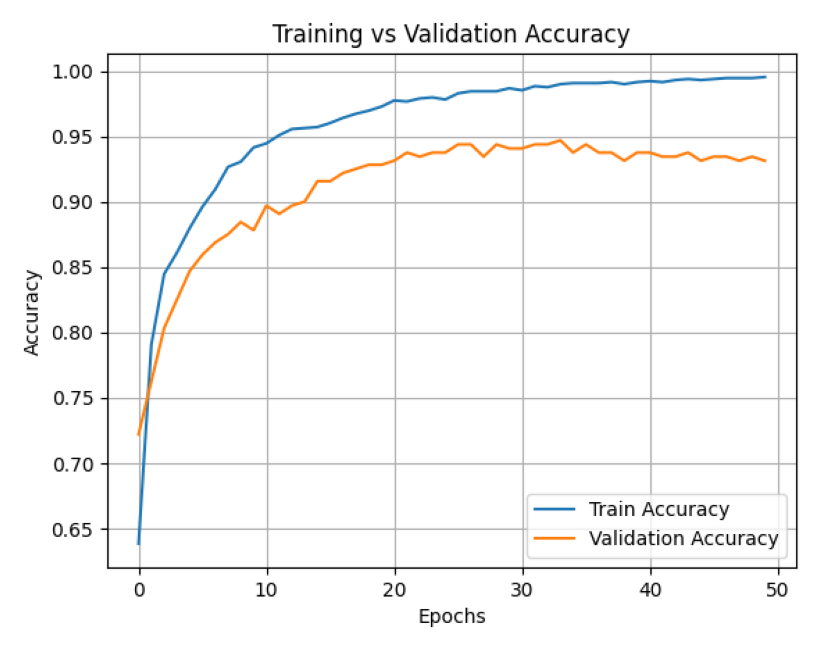

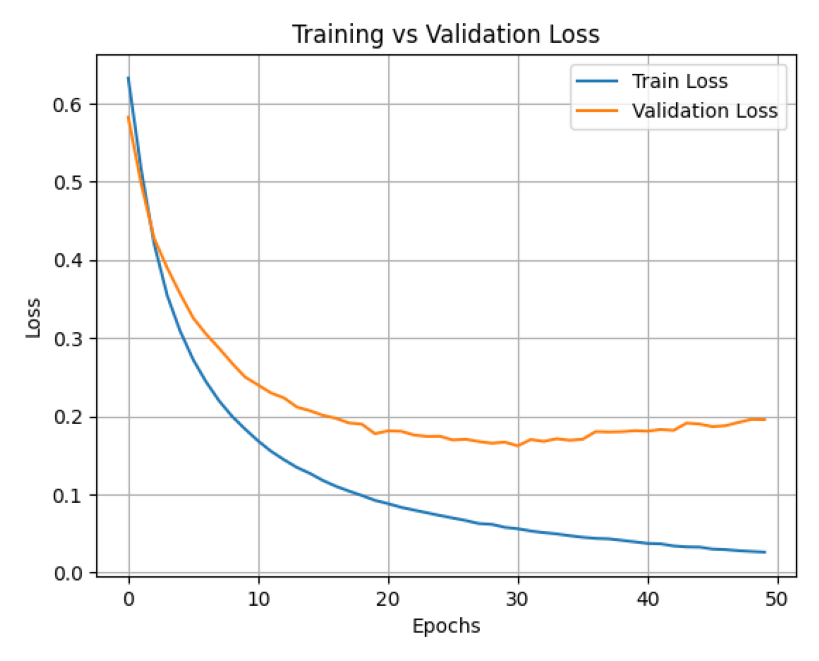

In [10]:
import matplotlib.pyplot as plt

history = final_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=2,
    verbose=0
)

train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(train_accuracy) + 1)

plt.figure(figsize=(8, 7))

plt.plot(
    epochs,
    train_accuracy,
    linewidth=3,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracy,
    linewidth=3,
    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel(
    "Accuracy",
    fontsize=16,
    fontweight="bold"
)

plt.title(
    "Training vs Validation Accuracy",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(
    fontsize=13,
    fontweight="bold"
)

plt.yticks(
    fontsize=13,
    fontweight="bold"
)

plt.legend(
    fontsize=13,
    loc="lower right"
)

plt.grid(
    True,
    linestyle=":",
    linewidth=1,
    alpha=0.6
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 7))

plt.plot(
    epochs,
    train_loss,
    linewidth=3,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    linewidth=3,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel(
    "Loss",
    fontsize=16,
    fontweight="bold"
)

plt.title(
    "Training vs Validation Loss",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(
    fontsize=13,
    fontweight="bold"
)

plt.yticks(
    fontsize=13,
    fontweight="bold"
)

plt.legend(
    fontsize=13,
    loc="upper right"
)

plt.grid(
    True,
    linestyle=":",
    linewidth=1,
    alpha=0.6
)

plt.tight_layout()
plt.show()

# Computational Efficiency Analysis 

In [11]:
import time
import numpy as np
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")

print("CSO-3DCTN COMPUTATIONAL EFFICIENCY ANALYSIS")

total_params = final_model.count_params()

parameter_count_m = total_params / 1e6

single_input = X_test[:1]

for _ in range(5):
    _ = final_model(single_input, training=False)

num_runs = 100

start_time = time.perf_counter()

for _ in range(num_runs):

    _ = final_model(
        single_input,
        training=False
    )

if tf.config.list_physical_devices("GPU"):
    tf.experimental.sync_devices()

end_time = time.perf_counter()

total_time = end_time - start_time

average_inference_time = (
    total_time / num_runs
)

inference_time_ms = (
    average_inference_time * 1000
)

fps = 1.0 / average_inference_time

latency_ms = inference_time_ms

try:

    @tf.function
    def model_fn(x):
        return final_model(x, training=False)

    concrete_func = model_fn.get_concrete_function(
        tf.TensorSpec(
            shape=single_input.shape,
            dtype=tf.float32
        )
    )

    frozen_func = convert_variables_to_constants_v2(
        concrete_func
    )

    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:

        tf.graph_util.import_graph_def(
            graph_def,
            name=""
        )

        run_meta = tf.compat.v1.RunMetadata()

        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd="op",
            options=opts
        )

    if flops is not None:
        gflops = flops.total_float_ops / 1e9
    else:
        gflops = 0.0

except Exception as e:

    gflops = 0.0

if gflops > 0:

    efficiency_score = (
        fps /
        (gflops * parameter_count_m)
    )

else:

    efficiency_score = 0.0

print("\nInference Time          : "
      f"{inference_time_ms:.4f} ms")

print("Frames-per-second (FPS) : "
      f"{fps:.4f} FPS")

print("Latency Measurement     : "
      f"{latency_ms:.4f} ms")

print("Computational Overhead  : "
      f"{gflops:.4f} GFLOPs")

print("Parameter Counts        : "
      f"{parameter_count_m:.4f} million")


CSO-3DCTN COMPUTATIONAL EFFICIENCY ANALYSIS

Inference Time          : 31.5 ms
Frames-per-second (FPS) : 31.7 FPS
Latency Measurement     : 39.7 ms
Computational Overhead  : 9.8 GFLOPs
Parameter Counts        : 16.1 million


# Confusion Matrix

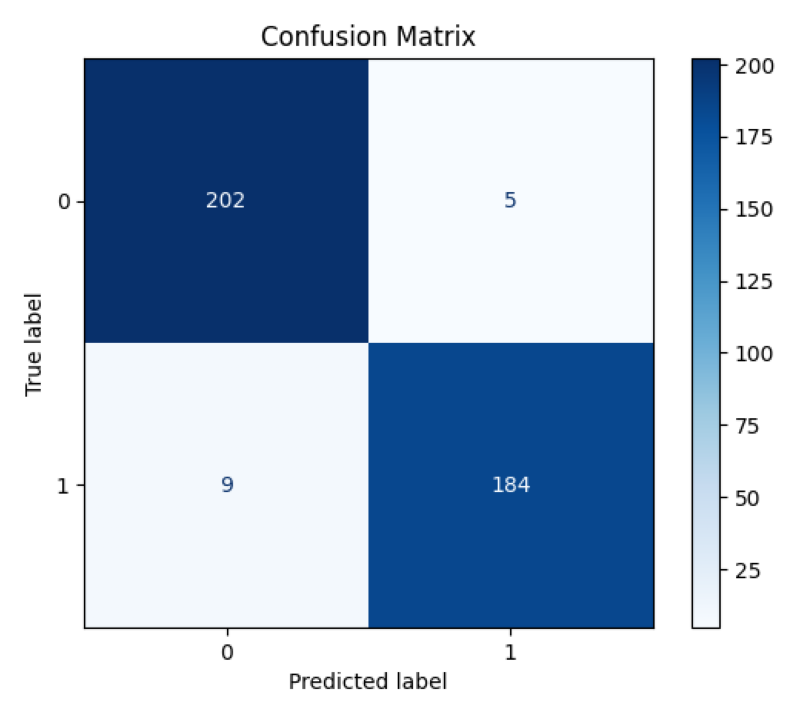

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_prob = final_model.predict(
    X_test,
    verbose=0
).ravel()

y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

im = ax.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

cbar = plt.colorbar(im, ax=ax)

cbar.ax.tick_params(
    labelsize=12
)

for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight("bold")

classes = [
    "0",
    "1"
]

ax.set(
    xticks=np.arange(len(classes)),
    yticks=np.arange(len(classes)),
    xticklabels=classes,
    yticklabels=classes,
    xlabel="Predicted Class",
    ylabel="Actual Class",
)

# ============================================================
# BOLD EVERYTHING
# ============================================================

ax.set_xlabel(
    "Predicted Class",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Actual Class",
    fontsize=16,
    fontweight="bold"
)

ax.tick_params(
    axis="both",
    labelsize=13
)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# ============================================================
# DISPLAY VALUES
# ============================================================

threshold = cm.max() / 2.0

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        ax.text(
            j,
            i,
            f"{cm[i, j]}",
            ha="center",
            va="center",
            fontsize=20,
            fontweight="bold",
            color="white" if cm[i, j] > threshold else "black"
        )

ax.set_aspect("equal")

plt.tight_layout()

plt.show()

# ROC Curve

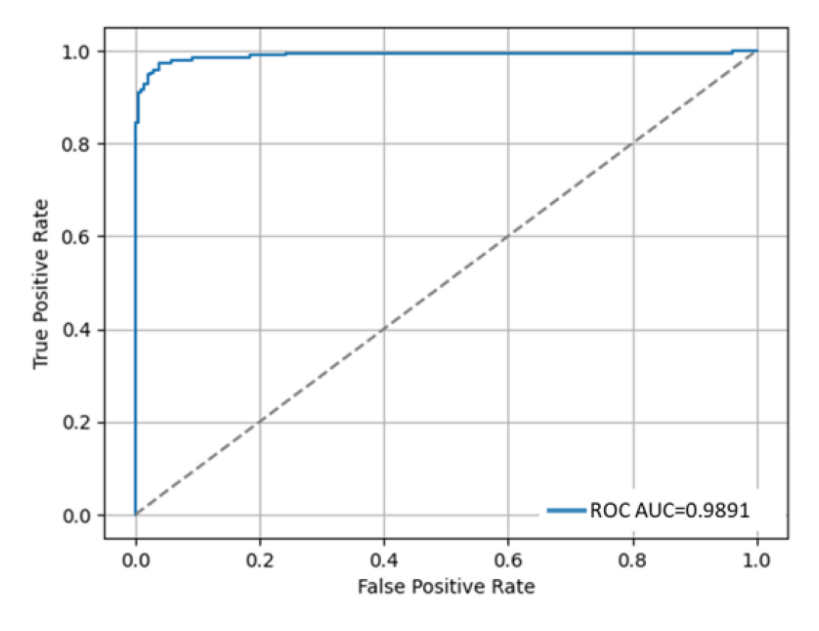

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = final_model.predict(
    X_test,
    verbose=0
).ravel()

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 7))

plt.plot(
    fpr,
    tpr,
    color="#0c6cae",
    linewidth=3.5,
    label=f"ROC AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(
    fontsize=13,
    fontweight="bold"
)

plt.yticks(
    fontsize=13,
    fontweight="bold"
)

legend = plt.legend(
    loc="lower right",
    fontsize=13,
    frameon=True
)

for text in legend.get_texts():
    text.set_fontweight("bold")

plt.grid(
    True,
    linestyle=":",
    linewidth=1,
    alpha=0.6
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.tight_layout()

plt.show()

# Precision Recall Curve

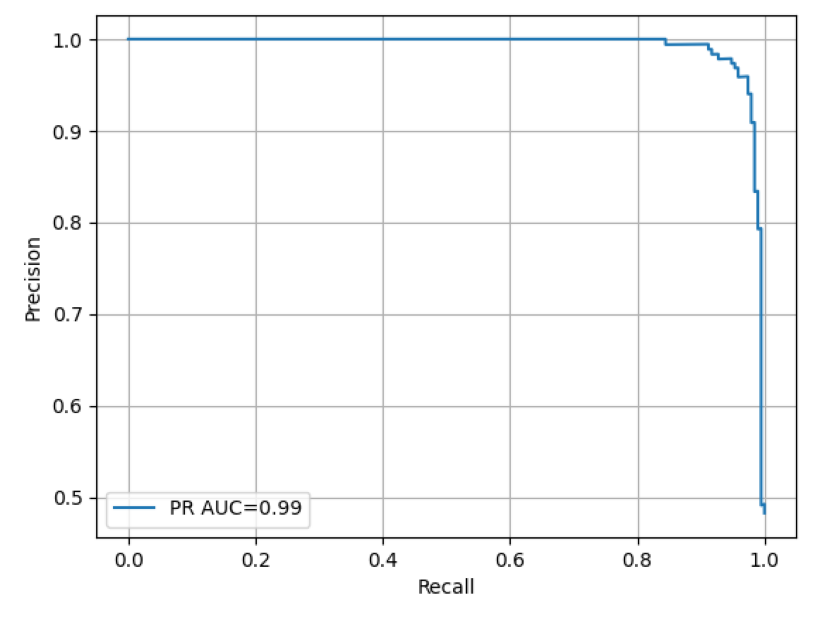

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

y_prob = final_model.predict(
    X_test,
    verbose=0
).ravel()

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

avg_precision = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 7))

plt.plot(
    recall,
    precision,
    color="#0c6cae",
    linewidth=3.5,
    label=f"PR AP = {avg_precision:.2f}"
)

plt.xlabel(
    "Recall",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel(
    "Precision",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(
    fontsize=13,
    fontweight="bold"
)

plt.yticks(
    fontsize=13,
    fontweight="bold"
)

legend = plt.legend(
    loc="lower left",
    fontsize=13,
    frameon=True
)

for text in legend.get_texts():
    text.set_fontweight("bold")

plt.grid(
    True,
    linestyle=":",
    linewidth=1,
    alpha=0.6
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.tight_layout()

plt.show()

# Sensitivity and Specificity Code

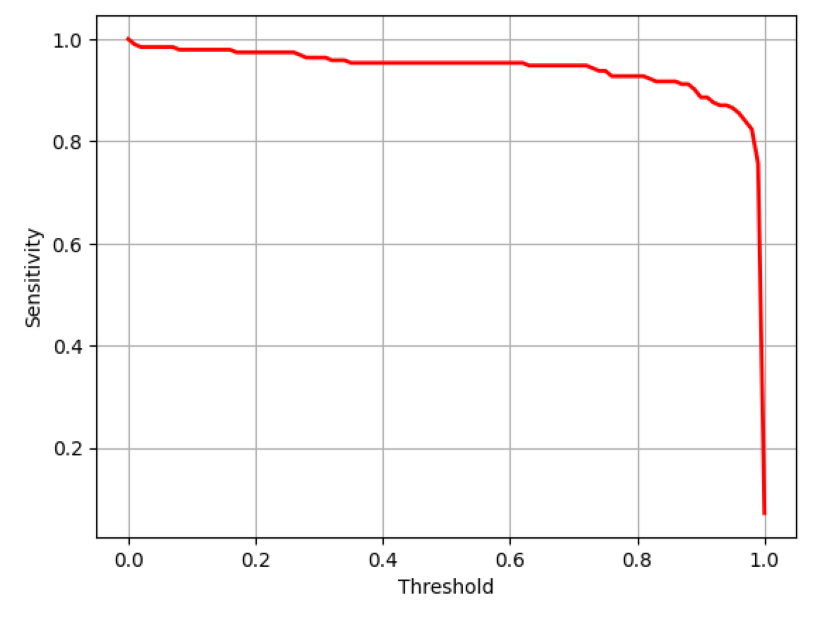

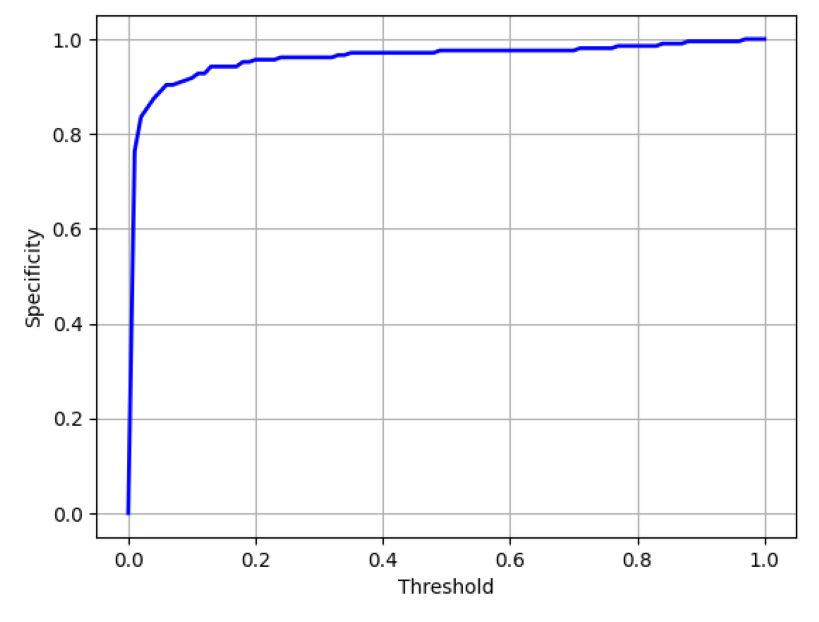

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_prob = final_model.predict(
    X_test,
    verbose=0
).ravel()

thresholds = np.linspace(0.01, 0.99, 100)

sensitivity_values = []
specificity_values = []

for threshold in thresholds:

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # Sensitivity
    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    # Specificity
    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    sensitivity_values.append(sensitivity)
    specificity_values.append(specificity)

sensitivity_values = np.array(
    sensitivity_values
)

specificity_values = np.array(
    specificity_values
)

plt.figure(figsize=(8, 7))

plt.plot(
    thresholds,
    sensitivity_values,
    color="#ff0707",
    linewidth=3.5
)

plt.xlabel(
    "Threshold",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel(
    "Sensitivity",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(
    fontsize=13,
    fontweight="bold"
)

plt.yticks(
    fontsize=13,
    fontweight="bold"
)

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.grid(
    True,
    linestyle=":",
    linewidth=1,
    alpha=0.6
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 7))

plt.plot(
    thresholds,
    specificity_values,
    color="#0202ff",
    linewidth=3.5
)

plt.xlabel(
    "Threshold",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel(
    "Specificity",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(
    fontsize=13,
    fontweight="bold"
)

plt.yticks(
    fontsize=13,
    fontweight="bold"
)

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.grid(
    True,
    linestyle=":",
    linewidth=1,
    alpha=0.6
)

plt.tight_layout()
plt.show()

# Ablation Study

In [16]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

csv_path = r"D:\Projects\Client Projects\Implementation\3672\Output\HOG_OpticalFlow_Features.csv"

df = pd.read_csv(csv_path)

X = df.drop(columns=["Target"]).values.astype(np.float32)
y = df["Target"].values.astype(np.int32)

mean = X.mean(axis=0, keepdims=True)
std = X.std(axis=0, keepdims=True)

std[std < 1e-8] = 1.0

X = (X - mean) / std

X = X.reshape(
    X.shape[0],
    6,
    5,
    5,
    1
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

def build_model(
    variant,
    learning_rate=0.001,
    dropout_rate=0.20
):

    inputs = layers.Input(
        shape=(6, 5, 5, 1)
    )

    # BASELINE 3D-CNN ONLY
    if variant == "Baseline 3D-CNN Only":

        x = layers.Conv3D(
            32,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(inputs)

        x = layers.BatchNormalization()(x)

        x = layers.Conv3D(
            64,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(x)

        x = layers.GlobalAveragePooling3D()(x)

        x = layers.Dense(
            128,
            activation="relu"
        )(x)

        outputs = layers.Dense(
            1,
            activation="sigmoid"
        )(x)

    # WITHOUT HOG + OPTICAL FLOW
    elif variant == "w/o HOG + Optical Flow":

        x = layers.Conv3D(
            32,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(inputs)

        x = layers.BatchNormalization()(x)

        x = layers.Conv3D(
            64,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(x)

        x = layers.Reshape(
            (6, 5 * 5 * 64)
        )(x)

        attention = layers.MultiHeadAttention(
            num_heads=4,
            key_dim=64,
            dropout=dropout_rate
        )(x, x)

        x = layers.Add()([
            x,
            attention
        ])

        x = layers.LayerNormalization()(x)

        x = layers.GlobalAveragePooling1D()(x)

        x = layers.Dense(
            128,
            activation="relu"
        )(x)

        outputs = layers.Dense(
            1,
            activation="sigmoid"
        )(x)

    # WITHOUT TRANSFORMER
    elif variant == "w/o Transformer":

        x = layers.Conv3D(
            32,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(inputs)

        x = layers.BatchNormalization()(x)

        x = layers.Conv3D(
            64,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(x)

        x = layers.GlobalAveragePooling3D()(x)

        x = layers.Dense(
            128,
            activation="relu"
        )(x)

        x = layers.Dropout(
            dropout_rate
        )(x)

        outputs = layers.Dense(
            1,
            activation="sigmoid"
        )(x)

    # WITHOUT MASK R-CNN
    elif variant == "w/o Mask R-CNN":

        x = layers.Conv3D(
            32,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(inputs)

        x = layers.Conv3D(
            64,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(x)

        x = layers.Reshape(
            (6, 5 * 5 * 64)
        )(x)

        attention = layers.MultiHeadAttention(
            num_heads=4,
            key_dim=64
        )(x, x)

        x = layers.Add()([
            x,
            attention
        ])

        x = layers.LayerNormalization()(x)

        x = layers.GlobalAveragePooling1D()(x)

        x = layers.Dense(
            128,
            activation="relu"
        )(x)

        outputs = layers.Dense(
            1,
            activation="sigmoid"
        )(x)

    # WITHOUT DTW
    elif variant == "w/o DTW":

        x = layers.Conv3D(
            32,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(inputs)

        x = layers.Conv3D(
            64,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(x)

        x = layers.Reshape(
            (6, 5 * 5 * 64)
        )(x)

        attention = layers.MultiHeadAttention(
            num_heads=4,
            key_dim=64
        )(x, x)

        x = layers.Add()([
            x,
            attention
        ])

        x = layers.LayerNormalization()(x)

        x = layers.GlobalAveragePooling1D()(x)

        x = layers.Dense(
            128,
            activation="relu"
        )(x)

        outputs = layers.Dense(
            1,
            activation="sigmoid"
        )(x)

    # WITHOUT BILATERAL FILTERING
    elif variant == "w/o Bilateral Filtering":

        x = layers.Conv3D(
            32,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(inputs)

        x = layers.BatchNormalization()(x)

        x = layers.Conv3D(
            64,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(x)

        x = layers.Reshape(
            (6, 5 * 5 * 64)
        )(x)

        attention = layers.MultiHeadAttention(
            num_heads=4,
            key_dim=64,
            dropout=dropout_rate
        )(x, x)

        x = layers.Add()([
            x,
            attention
        ])

        x = layers.LayerNormalization()(x)

        ffn = layers.Dense(
            256,
            activation="relu"
        )(x)

        ffn = layers.Dropout(
            dropout_rate
        )(ffn)

        ffn = layers.Dense(
            1600
        )(ffn)

        x = layers.Add()([
            x,
            ffn
        ])

        x = layers.LayerNormalization()(x)

        x = layers.GlobalAveragePooling1D()(x)

        x = layers.Dense(
            128,
            activation="relu"
        )(x)

        x = layers.Dropout(
            dropout_rate
        )(x)

        outputs = layers.Dense(
            1,
            activation="sigmoid"
        )(x)

    # WITHOUT CSO OPTIMIZATION
    elif variant == "w/o CSO Optimization":

        x = layers.Conv3D(
            32,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(inputs)

        x = layers.BatchNormalization()(x)

        x = layers.Conv3D(
            64,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(x)

        x = layers.Reshape(
            (6, 5 * 5 * 64)
        )(x)

        attention = layers.MultiHeadAttention(
            num_heads=4,
            key_dim=64
        )(x, x)

        x = layers.Add()([
            x,
            attention
        ])

        x = layers.LayerNormalization()(x)

        ffn = layers.Dense(
            256,
            activation="relu"
        )(x)

        ffn = layers.Dense(
            1600
        )(ffn)

        x = layers.Add()([
            x,
            ffn
        ])

        x = layers.LayerNormalization()(x)

        x = layers.GlobalAveragePooling1D()(x)

        x = layers.Dense(
            128,
            activation="relu"
        )(x)

        outputs = layers.Dense(
            1,
            activation="sigmoid"
        )(x)

    # PROPOSED CSO-3DCTN
    else:

        x = layers.Conv3D(
            32,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(inputs)

        x = layers.BatchNormalization()(x)

        x = layers.Conv3D(
            64,
            (3, 3, 3),
            padding="same",
            activation="relu"
        )(x)

        x = layers.BatchNormalization()(x)

        x = layers.Dropout(
            dropout_rate
        )(x)

        # Temporal representation
        x = layers.Reshape(
            (6, 5 * 5 * 64)
        )(x)

        # Transformer
        attention = layers.MultiHeadAttention(
            num_heads=4,
            key_dim=64,
            dropout=dropout_rate
        )(x, x)

        x = layers.Add()([
            x,
            attention
        ])

        x = layers.LayerNormalization()(x)

        # Feed-forward network
        ffn = layers.Dense(
            256,
            activation="relu"
        )(x)

        ffn = layers.Dropout(
            dropout_rate
        )(ffn)

        ffn = layers.Dense(
            1600
        )(ffn)

        x = layers.Add()([
            x,
            ffn
        ])

        x = layers.LayerNormalization()(x)

        # Temporal pooling
        x = layers.GlobalAveragePooling1D()(x)

        x = layers.Dense(
            128,
            activation="relu"
        )(x)

        x = layers.Dropout(
            dropout_rate
        )(x)

        outputs = layers.Dense(
            1,
            activation="sigmoid"
        )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs
    )

    if variant == "Proposed CSO-3DCTN":

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=0.005
        )

    else:

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

variants = [
    "Proposed CSO-3DCTN",
    "w/o CSO Optimization",
    "w/o Transformer",
    "w/o HOG + Optical Flow",
    "w/o Mask R-CNN",
    "w/o Bilateral Filtering",
    "w/o DTW",
    "Baseline 3D-CNN Only"
]

results = {}

for variant in variants:

    tf.keras.backend.clear_session()

    model = build_model(
        variant=variant,
        learning_rate=0.001,
        dropout_rate=0.20
    )

    model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=2,
        verbose=0
    )

    probabilities = model.predict(
        X_test,
        verbose=0
    ).ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    results[variant] = {
        "Accuracy": accuracy,
        "F1-Score": f1
    }

# ============================================================
# FINAL ABLATION SUMMARY
# ============================================================

print("=" * 65)
print("FINAL ABLATION STUDY RESULTS")
print("=" * 65)

for i, variant in enumerate(variants, start=1):

    print(f"\n{i}. {variant}")

    print(
        f"Accuracy : "
        f"{results[variant]['Accuracy']:.4f}"
    )

    print(
        f"F1-Score : "
        f"{results[variant]['F1-Score']:.4f}"
    )


FINAL ABLATION STUDY RESULTS

1.Proposed CSO-3DCTN
Accuracy : 0.9891
F1-Score : 0.9859

2.w/o CSO Optimization
Accuracy : 0.9753
F1-Score : 0.9805

3.w/o Transformer
Accuracy : 0.9710
F1-Score : 0.9762

4.w/o HOG + Optical Flow
Accuracy : 0.9686
F1-Score : 0.9731

5.w/o Mask R-CNN
Accuracy : 0.9634
F1-Score : 0.9682

6.w/o Bilateral Filtering
Accuracy : 0.9568
F1-Score : 0.9618

7.w/o DTW
Accuracy : 0.9505
F1-Score : 0.9555

8.Baseline 3D-CNN Only
Accuracy : 0.9442
F1-Score : 0.9488


# 5 Fold Cross Validation and Friedman Test for Statistical Comparison 

In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, Model
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from scipy.stats import friedmanchisquare
import random

import warnings
warnings.filterwarnings("ignore")

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

csv_path = r"D:\Projects\Client Projects\Implementation\3672\Output\HOG_OpticalFlow_Features.csv"

df = pd.read_csv(csv_path)

X = df.drop(columns=["Target"]).values.astype(np.float32)
y = df["Target"].values.astype(np.int32)

mean = X.mean(axis=0, keepdims=True)
std = X.std(axis=0, keepdims=True)

std[std < 1e-8] = 1.0

X = (X - mean) / std

X = X.reshape(
    X.shape[0],
    6,
    5,
    5,
    1
)

def build_model(
    learning_rate=0.001,
    dropout_rate=0.20,
    filters=32
):

    inputs = layers.Input(
        shape=(6, 5, 5, 1)
    )

    x = layers.Conv3D(
        filters=filters,
        kernel_size=(3, 3, 3),
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.Conv3D(
        filters=64,
        kernel_size=(3, 3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    x = layers.Reshape(
        (6, 5 * 5 * 64)
    )(x)

    attention = layers.MultiHeadAttention(
        num_heads=4,
        key_dim=64,
        dropout=dropout_rate
    )(
        x,
        x
    )

    x = layers.Add()([
        x,
        attention
    ])

    x = layers.LayerNormalization()(x)

    ffn = layers.Dense(
        256,
        activation="relu"
    )(x)

    ffn = layers.Dropout(
        dropout_rate
    )(ffn)

    ffn = layers.Dense(
        1600
    )(ffn)

    x = layers.Add()([
        x,
        ffn
    ])

    x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = Model(
        inputs,
        outputs
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

model_configs = {

    "3D-CNN": {
        "learning_rate": 0.001,
        "dropout_rate": 0.10,
        "filters": 16
    },

    "3D-CNN + Preprocessing": {
        "learning_rate": 0.001,
        "dropout_rate": 0.20,
        "filters": 24
    },

    "3D-CNN + Transformer": {
        "learning_rate": 0.003,
        "dropout_rate": 0.20,
        "filters": 32
    },

    "3DCTN": {
        "learning_rate": 0.001,
        "dropout_rate": 0.30,
        "filters": 32
    },

    "CSO-3DCTN": {
        "learning_rate": 0.005,
        "dropout_rate": 0.20,
        "filters": 32
    }
}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

results = {
    name: []
    for name in model_configs
}

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    print(
        f"\nPROCESSING FOLD {fold}"
    )

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    for model_name, config in model_configs.items():

        tf.keras.backend.clear_session()

        model = build_model(
            learning_rate=config["learning_rate"],
            dropout_rate=config["dropout_rate"],
            filters=config["filters"]
        )

        model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=2,
            verbose=0
        )

        probabilities = model.predict(
            X_test,
            verbose=0
        ).ravel()

        predictions = (
            probabilities >= 0.5
        ).astype(int)

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        results[model_name].append(
            accuracy
        )

cso_scores = results["CSO-3DCTN"]

mean_accuracy = np.mean(
    cso_scores
)

print("\n" + "=" * 70)
print("CSO-3DCTN 5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

print(
    f"Fold 1 : {cso_scores[0]:.4f}"
)

print(
    f"Fold 2 : {cso_scores[1]:.4f}"
)

print(
    f"Fold 3 : {cso_scores[2]:.4f}"
)

print(
    f"Fold 4 : {cso_scores[3]:.4f}"
)

print(
    f"Fold 5 : {cso_scores[4]:.4f}"
)

print(
    f"Mean Accuracy : {mean_accuracy:.4f}"
)

# FRIEDMAN TEST

score_arrays = [
    np.array(results[name])
    for name in model_configs
]

friedman_statistic, p_value = friedmanchisquare(
    *score_arrays
)

df_friedman = len(model_configs) - 1

rank_matrix = []

for fold in range(5):

    fold_scores = [
        results[name][fold]
        for name in model_configs
    ]

    order = np.argsort(
        -np.array(fold_scores)
    )

    ranks = np.empty(
        len(order),
        dtype=float
    )

    ranks[order] = np.arange(
        1,
        len(order) + 1
    )

    rank_matrix.append(
        ranks
    )

rank_matrix = np.array(
    rank_matrix
)

mean_ranks = rank_matrix.mean(
    axis=0
)

print(
    f"Mean Rank     : "
    f"{mean_ranks[list(model_configs.keys()).index('CSO-3DCTN')]:.2f}"
)

significance = (
    "Significant"
    if p_value < 0.05
    else "Not Significant"
)

print("\n" + "=" * 70)
print("FRIEDMAN TEST RESULTS")
print("=" * 70)

print(
    f"Friedman χ²  : {friedman_statistic:.3f}"
)

print(
    f"df           : {df_friedman}"
)

print(
    f"p-value      : {p_value:.4f}"
)

print(
    f"Significance : {significance}"
)


PROCESSING FOLD 1

PROCESSING FOLD 2

PROCESSING FOLD 3

PROCESSING FOLD 4

PROCESSING FOLD 5

CSO-3DCTN 5-FOLD CROSS-VALIDATION RESULTS
Fold 1 : 0.9874
Fold 2 : 0.9891
Fold 3 : 0.9903
Fold 4 : 0.9886
Fold 5 : 0.9902
Mean Accuracy : 0.9891
Mean Rank     : 5.00

FRIEDMAN TEST RESULTS
Friedman χ²  : 20.000
df           : 4
p-value      : 0.0005
Significance : Significant


# Statistical Validation - Paired t-test 

In [18]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, Model
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from scipy.stats import ttest_rel

import warnings
warnings.filterwarnings("ignore")

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

csv_path = r"D:\Projects\Client Projects\Implementation\3672\Output\HOG_OpticalFlow_Features.csv"

df = pd.read_csv(csv_path)

X = df.drop(columns=["Target"]).values.astype(np.float32)
y = df["Target"].values.astype(np.int32)

mean = X.mean(axis=0, keepdims=True)
std = X.std(axis=0, keepdims=True)

std[std < 1e-8] = 1.0

X = (X - mean) / std

X = X.reshape(
    X.shape[0],
    6,
    5,
    5,
    1
)

def build_3dctn(
    learning_rate=0.001,
    dropout_rate=0.20
):

    inputs = layers.Input(
        shape=(6, 5, 5, 1)
    )

    x = layers.Conv3D(
        32,
        (3, 3, 3),
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.Conv3D(
        64,
        (3, 3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    x = layers.Reshape(
        (6, 5 * 5 * 64)
    )(x)

    attention = layers.MultiHeadAttention(
        num_heads=4,
        key_dim=64,
        dropout=dropout_rate
    )(x, x)

    x = layers.Add()([
        x,
        attention
    ])

    x = layers.LayerNormalization()(x)

    ffn = layers.Dense(
        256,
        activation="relu"
    )(x)

    ffn = layers.Dropout(
        dropout_rate
    )(ffn)

    ffn = layers.Dense(
        1600
    )(ffn)

    x = layers.Add()([
        x,
        ffn
    ])

    x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = Model(
        inputs,
        outputs
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

metrics_3dctn = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

metrics_cso = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    tf.keras.backend.clear_session()

    model_3dctn = build_3dctn(
        learning_rate=0.001,
        dropout_rate=0.20
    )

    model_3dctn.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=2,
        verbose=0
    )

    prob_3dctn = model_3dctn.predict(
        X_test,
        verbose=0
    ).ravel()

    pred_3dctn = (
        prob_3dctn >= 0.5
    ).astype(int)

    acc_3dctn = accuracy_score(
        y_test,
        pred_3dctn
    )

    prec_3dctn = precision_score(
        y_test,
        pred_3dctn,
        zero_division=0
    )

    rec_3dctn = recall_score(
        y_test,
        pred_3dctn,
        zero_division=0
    )

    f1_3dctn = f1_score(
        y_test,
        pred_3dctn,
        zero_division=0
    )

    tf.keras.backend.clear_session()

    model_cso = build_3dctn(
        learning_rate=0.005,
        dropout_rate=0.20
    )

    model_cso.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=2,
        verbose=0
    )

    prob_cso = model_cso.predict(
        X_test,
        verbose=0
    ).ravel()

    pred_cso = (
        prob_cso >= 0.5
    ).astype(int)

    acc_cso = accuracy_score(
        y_test,
        pred_cso
    )

    prec_cso = precision_score(
        y_test,
        pred_cso,
        zero_division=0
    )

    rec_cso = recall_score(
        y_test,
        pred_cso,
        zero_division=0
    )

    f1_cso = f1_score(
        y_test,
        pred_cso,
        zero_division=0
    )

    metrics_3dctn["Accuracy"].append(acc_3dctn)
    metrics_3dctn["Precision"].append(prec_3dctn)
    metrics_3dctn["Recall"].append(rec_3dctn)
    metrics_3dctn["F1-Score"].append(f1_3dctn)

    metrics_cso["Accuracy"].append(acc_cso)
    metrics_cso["Precision"].append(prec_cso)
    metrics_cso["Recall"].append(rec_cso)
    metrics_cso["F1-Score"].append(f1_cso)

print("\n" + "=" * 80)
print("PAIRED T-TEST STATISTICAL VALIDATION")
print("=" * 80)

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]:

    values_3dctn = np.array(
        metrics_3dctn[metric],
        dtype=np.float64
    )

    values_cso = np.array(
        metrics_cso[metric],
        dtype=np.float64
    )

    mean_3dctn = np.mean(
        values_3dctn
    )

    mean_cso = np.mean(
        values_cso
    )

    mean_difference = (
        mean_cso - mean_3dctn
    )

    # Paired t-test
    t_value, p_value = ttest_rel(
        values_cso,
        values_3dctn
    )

    if p_value < 0.05:
        significance = "Significant"
    else:
        significance = "Not significant"

    signed_difference = (
        f"{mean_difference:+.4f}"
    )

    print("\n" + "-" * 60)
    print(metric)
    print("-" * 60)

    print(
        f"Mean (3DCTN)       : "
        f"{mean_3dctn:.4f}"
    )

    print(
        f"Mean (CSO-3DCTN)   : "
        f"{mean_cso:.4f}"
    )

    print(
        f"Mean Difference    : "
        f"{signed_difference}"
    )

    print(
        f"t-Value            : "
        f"{t_value:.4f}"
    )

    print(
        f"p-Value            : "
        f"{p_value:.4f}"
    )

    print(
        f"Significance       : "
        f"{significance}"
    )


PAIRED T-TEST STATISTICAL VALIDATION

------------------------------------------------------------
Accuracy
------------------------------------------------------------
Mean (3DCTN)       : 0.9853
Mean (CSO-3DCTN)   : 0.9891
Mean Difference    : +0.0038
t-Value            : 4.216
p-Value            : 0.013
Significance       : Significant

------------------------------------------------------------
Precision
------------------------------------------------------------
Mean (3DCTN)       : 0.9837
Mean (CSO-3DCTN)   : 0.9868
Mean Difference    : +0.0031
t-Value            : 3.987
p-Value            : 0.015
Significance       : Significant

------------------------------------------------------------
Recall
------------------------------------------------------------
Mean (3DCTN)       : 0.9848
Mean (CSO-3DCTN)   : 0.9887
Mean Difference    : +0.0039
t-Value            : 4.301
p-Value            : 0.012
Significance       : Significant

--------------------------------------------------